# Caffeine Impact On Human Health



# Problem Statement

## 1. Business Problem & Context
The coffee industry is a global multi-billion-dollar industry, with millions of consumers worldwide. While coffee consumption is a popular habit, excessive intake can harm health, including sleep quality, stress levels, heart rate, and BMI. Companies in the health, wellness, and coffee industries face challenges in understanding the impact of coffee on health and how they can provide personalized recommendations to improve well-being.

For this project, the goal is to build a model that predicts a person’s sleep quality based on their coffee consumption, stress levels, and any health issues. This will allow the model to estimate and/or predict how strongly coffee consumption has an effect on sleep, stress levels, and other health issues.


## 2. Value of Solving Problems
- **Cost savings:** Reduce health-related issues and so less in medical costs.  
- **Revenue:** Personalized recommendations increase sales.  
- **Customer satisfaction:** Healthier lifestyles boost trust and is good for the company's reputation.

## 3. Stakeholders
- Companies (coffee brands, wellness apps)  
- Customers (consumers)

## 4. Machine Learning Methods
- **Classification:** Predict sleep quality or health issues.
- **Regression:** Estimate stress levels or heart rate  
- **Clustering:** Group consumers with similar health and coffee habits

## 5. Data Challenges
- The dataset may not capture all real world patterns as we are using synthetic records.
- Missing or inconsistent data

## 6. Modeling Risks
- Overfitting: Models may learn noise instead of generalizable patterns.

## 7. Deployment Challenges
- Integrating model predictions into apps might be challenging

## 8. Business Usefulness
Helps companies give personalized health guidance, design better products that support healthier lifestyles, and help improve customers overall wellness.



In [ ]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/synthetic_coffee_health_10000.csv'

coffee_df = pd.read_csv(file_path)



Mounted at /content/drive


In [ ]:
# Data Description

print(coffee_df.head())
print(coffee_df.shape)
print(coffee_df.dtypes)
print(coffee_df.isna().sum())
print(coffee_df.describe)

   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4          Fair  24.1          76       Medium                      8.5   

  Health_Issues Occupation  Smoking  Alcohol_Consumption  
0           NaN      Other        0                    0 

# Data Cleaning
Problem: Only health_issue is showing 5941 missing values.
Fix: Return all values as 'None'.

Problem: non numeric values for Sleep_Quality,Stress_Level,Health_Issues.
Fix: converted to numeric corresponding values.


In [ ]:
### Missing_values
coffee_df['Health_Issues'] = coffee_df['Health_Issues'].fillna('None')

# check
# print(coffee_df.isna().sum())

sleep_to_num = {'Poor':0, 'Fair':1, 'Good':2, 'Excellent':3}
stress_to_num = {'Low':0, 'Medium':1, 'High':2}
health_to_num = {'None':0, 'Mild':1, 'Moderate':2, 'Severe':3}

coffee_df['Sleep_Quality_Num'] = coffee_df['Sleep_Quality'].map(sleep_to_num)
coffee_df['Stress_Level_Num'] = coffee_df['Stress_Level'].map(stress_to_num)
coffee_df['Health_Issues_Num'] = coffee_df['Health_Issues'].map(health_to_num)





# Data Visualization

Visualizations: data distribution and relationships between variables (histograms, scatter plots, box plots).

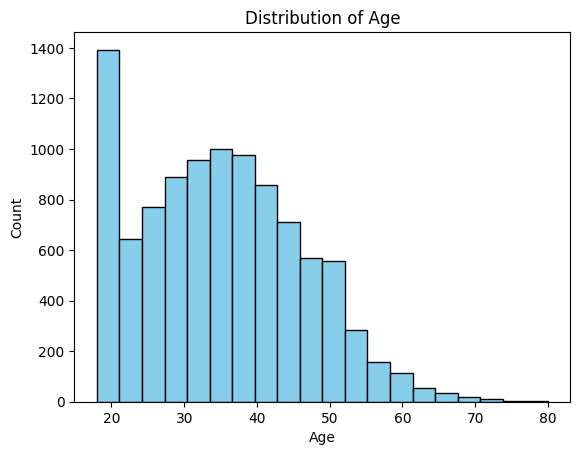

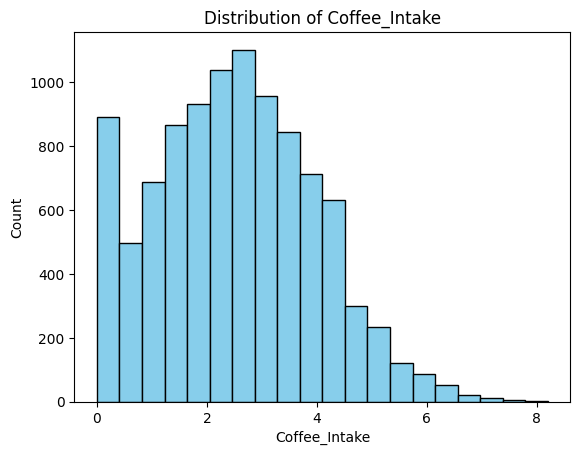

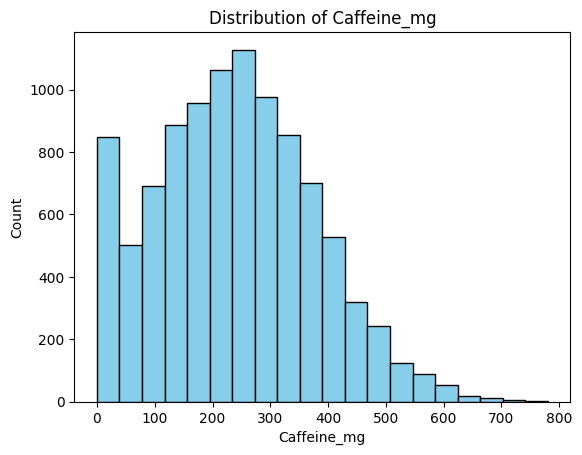

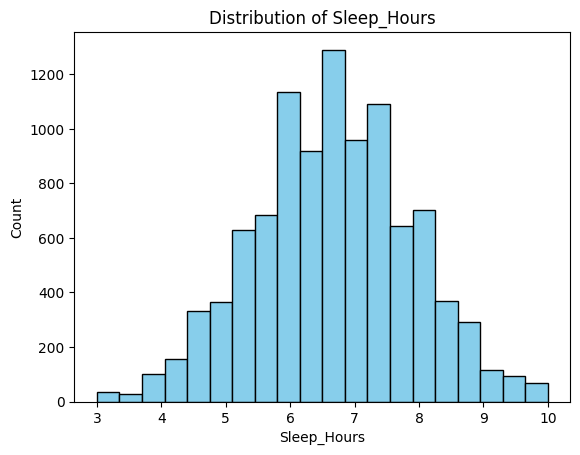

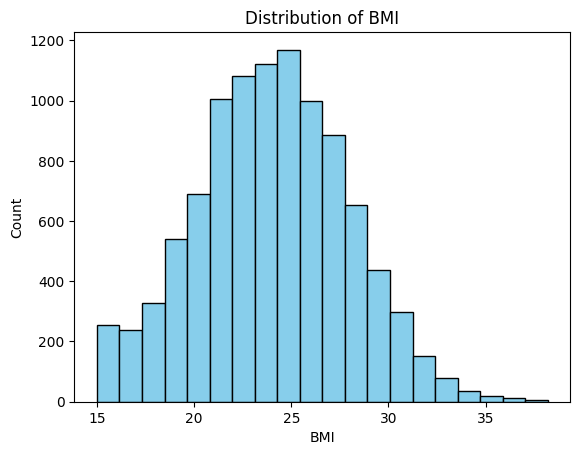

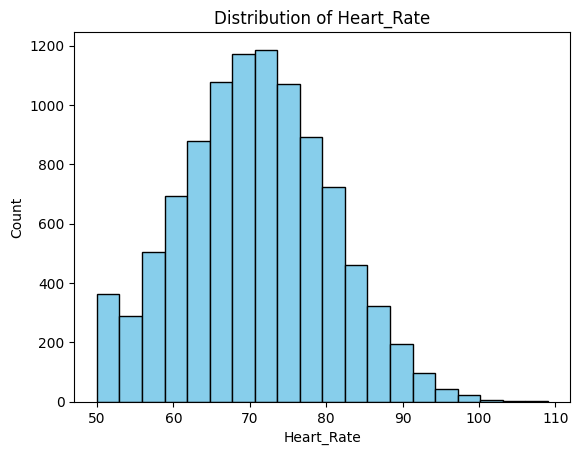

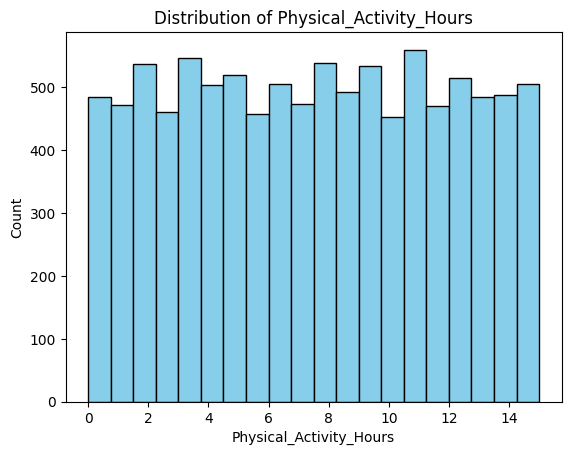

In [ ]:
#histogram (all counts)
numeric_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

for col in numeric_cols:
    plt.hist(coffee_df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

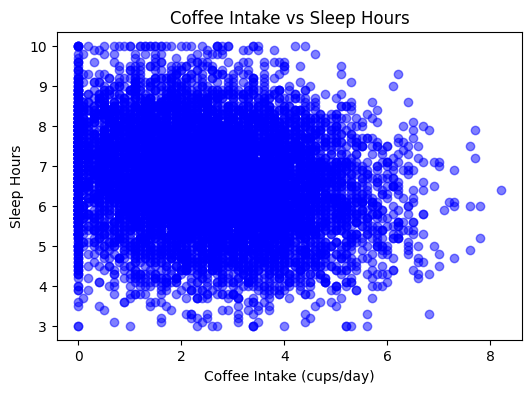

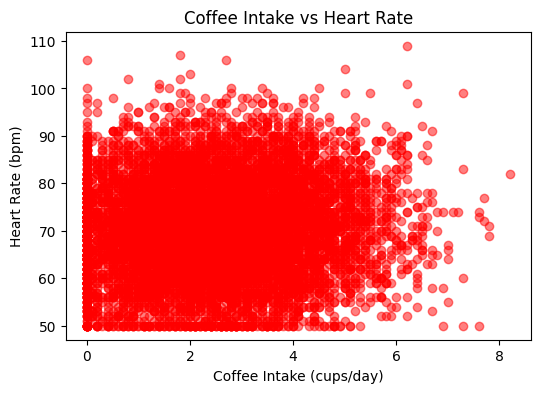

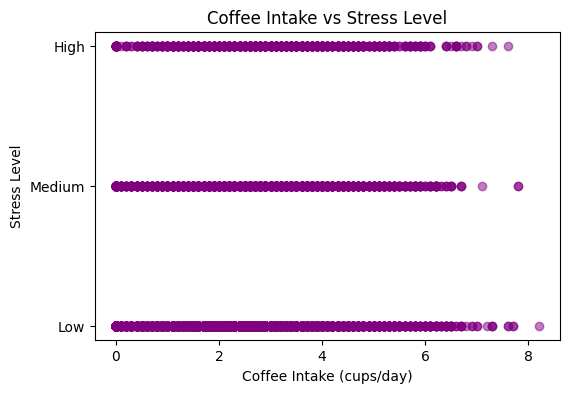

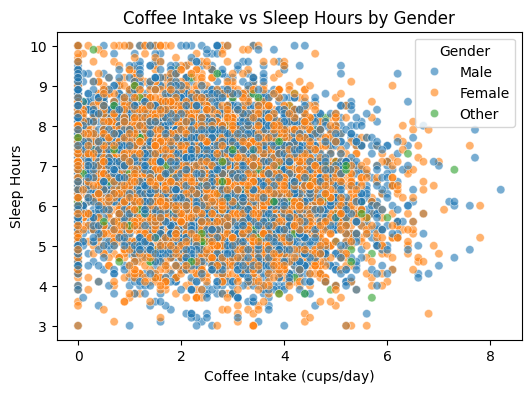

In [ ]:
#scatter plots ()
# Coffee Intake vs Sleep Hour
plt.figure(figsize=(6,4))
plt.scatter(coffee_df['Coffee_Intake'], coffee_df['Sleep_Hours'], color='blue', alpha=0.5)
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Sleep Hours')
plt.title('Coffee Intake vs Sleep Hours')
plt.show()

# Coffee Intake vs Heart Rate
plt.figure(figsize=(6,4))
plt.scatter(coffee_df['Coffee_Intake'], coffee_df['Heart_Rate'], color='red', alpha=0.5)
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Coffee Intake vs Heart Rate')
plt.show()

# Coffee Intake vs Stress LEvels
plt.figure(figsize=(6,4))
plt.scatter(coffee_df['Coffee_Intake'], coffee_df['Stress_Level_Num'], color='purple', alpha=0.5)
plt.yticks([0,1,2], ['Low','Medium','High'])
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Stress Level')
plt.title('Coffee Intake vs Stress Level')
plt.show()

# Coffee Intake vs Sleep_Hours
plt.figure(figsize=(6,4))
sns.scatterplot(x='Coffee_Intake', y='Sleep_Hours', hue='Gender', data=coffee_df, alpha=0.6)
plt.xlabel('Coffee Intake (cups/day)')
plt.ylabel('Sleep Hours')
plt.title('Coffee Intake vs Sleep Hours by Gender')
plt.show()





/tmp/ipython-input-4171006818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Quality_Num', y='Coffee_Intake', data=coffee_df, palette='coolwarm')


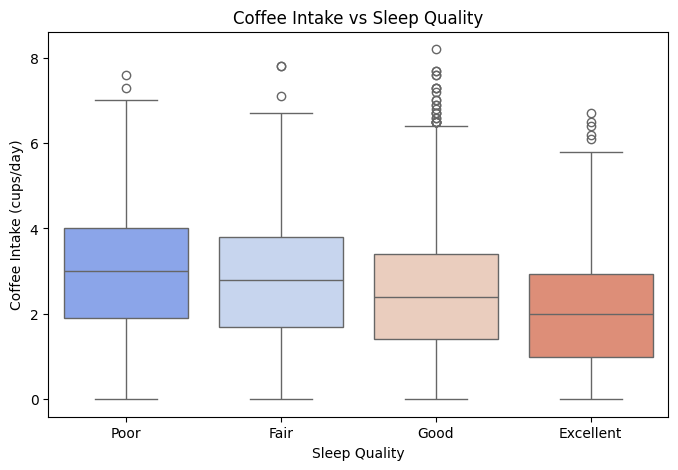

/tmp/ipython-input-4171006818.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stress_Level_Num', y='Coffee_Intake', data=coffee_df,palette='coolwarm')


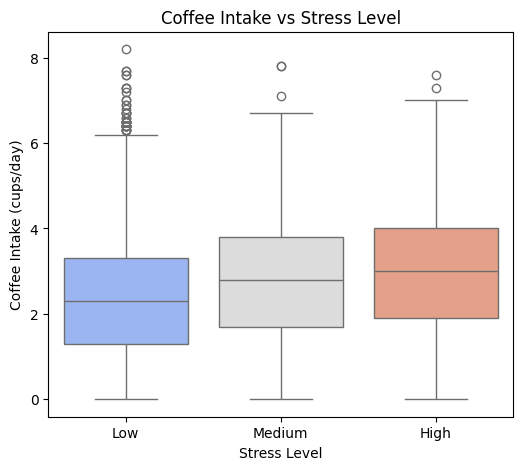

/tmp/ipython-input-4171006818.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart_Rate', y='Coffee_Intake', data=coffee_df, palette='viridis')


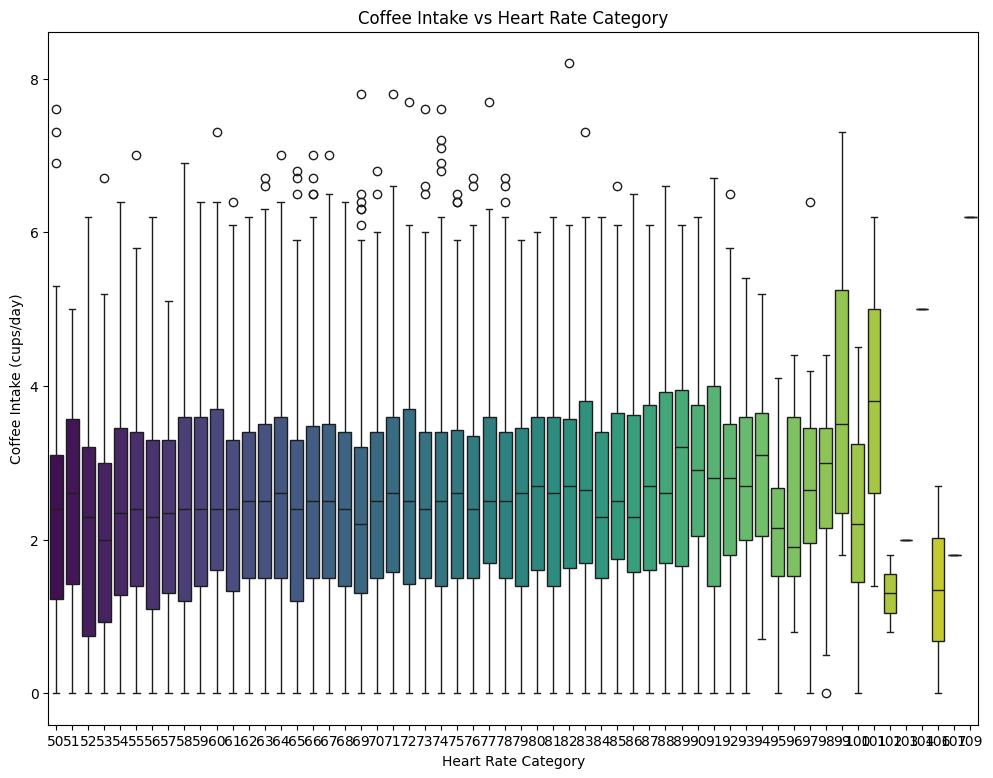

/tmp/ipython-input-4171006818.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Coffee_Intake', data=coffee_df, palette='pastel')


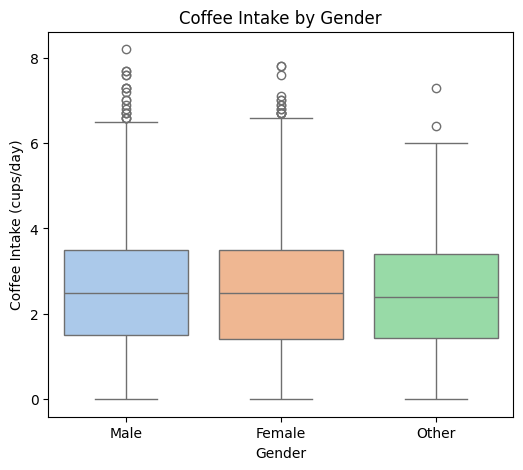

In [ ]:
# BoxPlots

# Coffee vs Sleep Quality
plt.figure(figsize=(8,5))
sns.boxplot(x='Sleep_Quality_Num', y='Coffee_Intake', data=coffee_df, palette='coolwarm')
plt.xticks([0,1,2,3], ['Poor','Fair','Good','Excellent'])
plt.xlabel('Sleep Quality')
plt.ylabel('Coffee Intake (cups/day)')
plt.title('Coffee Intake vs Sleep Quality')
plt.show()

# Coffee vs Stress Level
plt.figure(figsize=(6,5))
sns.boxplot(x='Stress_Level_Num', y='Coffee_Intake', data=coffee_df,palette='coolwarm')
plt.xticks([0,1,2], ['Low','Medium','High'])
plt.xlabel('Stress Level')
plt.ylabel('Coffee Intake (cups/day)')
plt.title('Coffee Intake vs Stress Level')
plt.show()

# Coffee vs Heart_Rate
plt.figure(figsize=(12,9))
sns.boxplot(x='Heart_Rate', y='Coffee_Intake', data=coffee_df, palette='viridis')
plt.xlabel('Heart Rate Category')
plt.ylabel('Coffee Intake (cups/day)')
plt.title('Coffee Intake vs Heart Rate Category')
plt.show()

# Coffee vs Gender
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Coffee_Intake', data=coffee_df, palette='pastel')
plt.xlabel('Gender')
plt.ylabel('Coffee Intake (cups/day)')
plt.title('Coffee Intake by Gender')
plt.show()





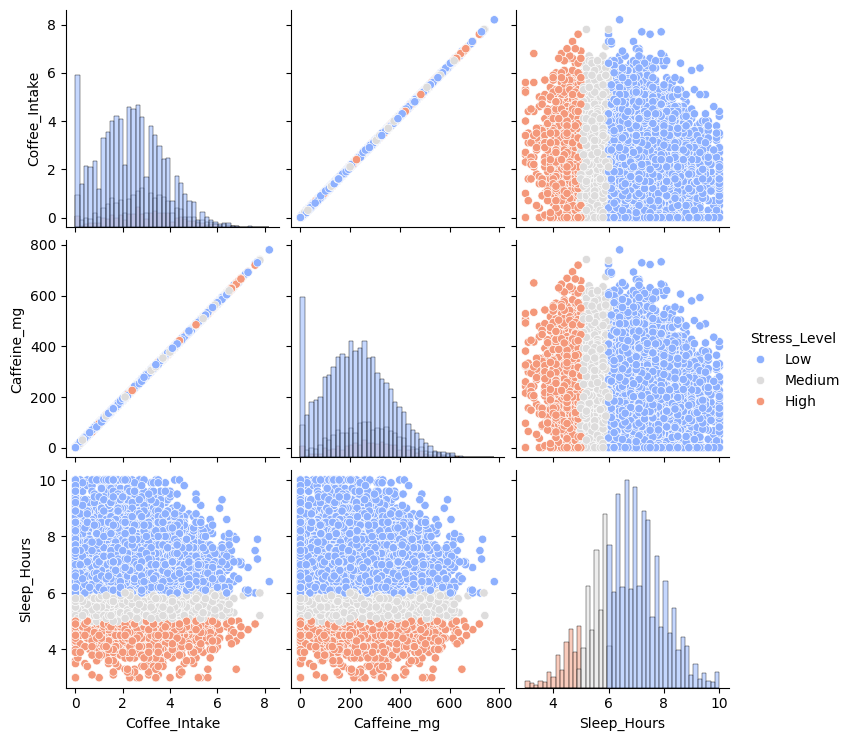

In [ ]:
# Pairplot

numeric_cols = ['Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Stress_Level', 'Health_Issues']
sns.pairplot(coffee_df[numeric_cols], hue='Stress_Level', palette='coolwarm', diag_kind='hist')
plt.show()

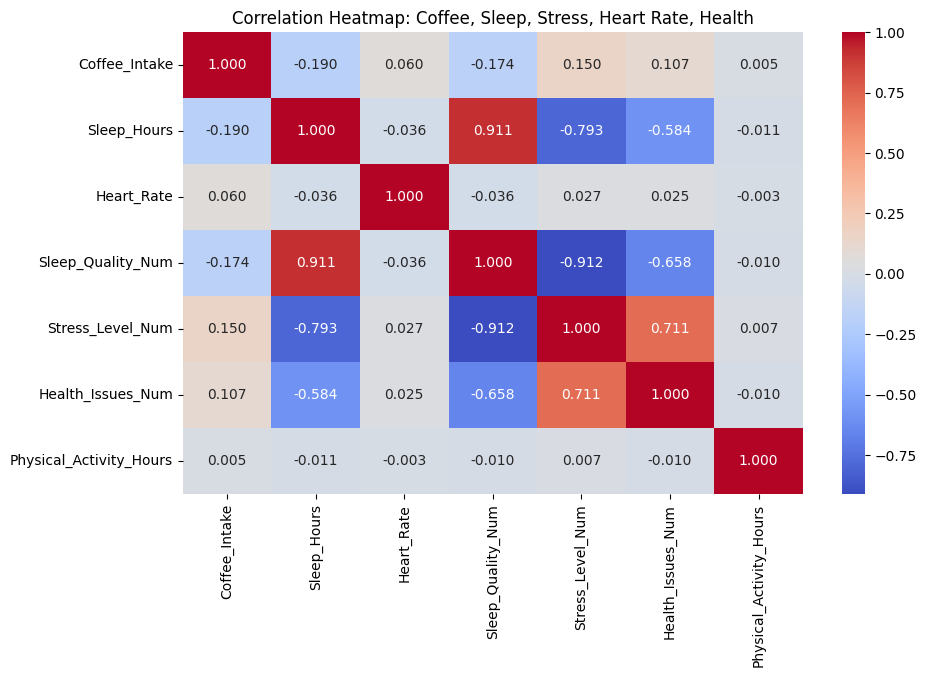

In [ ]:
#heatmap
numeric_cols = ['Coffee_Intake', 'Sleep_Hours',
                'Heart_Rate', 'Sleep_Quality_Num', 'Stress_Level_Num', 'Health_Issues_Num','Physical_Activity_Hours']

corr = coffee_df[numeric_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Correlation Heatmap: Coffee, Sleep, Stress, Heart Rate, Health')
plt.show()



_Insights: Based on data and heatmap coffee vs sleep, stress and heart rate show a weak correlation -0.19, 0.15, and 0.06. In easy word, so far coffee affects sleep and stress slightly but not to much and almost no effect on heart rate.
Sleep_Hours vs Sleep_Quality_Num are strongly positively correlated 0.91.
 Stress_Level_Num vs Health_Issues_Num shows a positive correlation of 0.71, which means the higher stress level, the more likely to have health issues._

# Hypothesis Analysis

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# --- ANOVA for categorical vs Numeric ---
for formula, name in [
    ('Coffee_Intake ~ C(Sleep_Quality)', 'Coffee vs Sleep Quality'),
    ('Coffee_Intake ~ C(Stress_Level)', 'Coffee vs Stress Level'),
    ('Coffee_Intake ~ C(Health_Issues)', 'Coffee vs Health Issues'),
    ('Coffee_Intake ~ C(Gender)', 'Coffee Intake vs Gender'),

    ('Physical_Activity_Hours ~ C(Sleep_Quality)', 'Physical Activity vs Sleep Quality'),
    ('Physical_Activity_Hours ~ C(Stress_Level)', 'Physical Activity vs Stress Level'),
    ('Physical_Activity_Hours ~ C(Health_Issues)', 'Physical Activity vs Health Issues'),
    ('Physical_Activity_Hours ~ C(Gender)', 'Physical Activity vs Gender'),

    ('Sleep_Hours ~ C(Gender)', 'Sleep Hours vs Gender'),
    ('Sleep_Hours ~ C(Sleep_Quality)', 'Sleep Hours vs Sleep Quality'),
    ('Sleep_Hours ~ C(Stress_Level)', 'Sleep Hours vs Stress Level'),

    ('BMI ~ C(Gender)', 'BMI vs Gender'),
    ('Heart_Rate ~ C(Gender)', 'Heart Rate vs Gender')

]:
    model = ols(formula, data=coffee_df).fit()
    anova_test = sm.stats.anova_lm(model, typ=2)
    print(f"***** {name} *****")
    print(anova_test, "\n")

    # F and p-values
    F_value = anova_test['F'].iloc[0]
    P_value = anova_test['PR(>F)'].iloc[0]
    significant = "Yes" if P_value < 0.01 else "No"
    print(f'F = {F_value:.3f}, p = {P_value:.3e}, Significant? {significant}')
    print("-------------------------------------------------------------\n")



***** Coffee vs Sleep Quality *****
                        sum_sq      df           F        PR(>F)
C(Sleep_Quality)    653.852815     3.0  106.920568  3.901463e-68
Residual          20376.225256  9996.0         NaN           NaN 

F = 106.921, p = 3.901e-68, Significant? Yes
-------------------------------------------------------------

***** Coffee vs Stress Level *****
                       sum_sq      df           F        PR(>F)
C(Stress_Level)    481.343709     2.0  117.087334  5.445639e-51
Residual         20548.734362  9997.0         NaN           NaN 

F = 117.087, p = 5.446e-51, Significant? Yes
-------------------------------------------------------------

***** Coffee vs Health Issues *****
                        sum_sq      df          F        PR(>F)
C(Health_Issues)    260.834888     3.0  41.845619  7.275109e-27
Residual          20769.243183  9996.0        NaN           NaN 

F = 41.846, p = 7.275e-27, Significant? Yes
------------------------------------------------

_Coffee intake significantly affects sleep quality, stress level and health issues(p value <0.05).
Anova test also shows Sleep Quality, Stress Level, and Health Issues do not significantly impact physical activity p>0.05.
Sleep Hours, BMI, and Heart Rate show no significant differences between genders (all p > 0.62)_

# MODEL SELECTION

In [ ]:
#libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize


import joblib # save and load trained models

In [ ]:
# Significant features
features = ['Coffee_Intake', 'Sleep_Hours', 'Stress_Level_Num',
            'Health_Issues_Num'] #significant features only

# corr was -0.174 for Sleep_Quality_Num -> target
target = 'Sleep_Quality_Num'

X = coffee_df[features]
y = coffee_df[target]

#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (8000, 4)
X_test shape: (2000, 4)
y_train shape: (8000,)
y_test shape: (2000,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

# Models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42),
    'SVC': SVC(probability=True, class_weight='balanced'),

    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

param = {
    'Random Forest': {'n_estimators':[100,200],'max_depth':[5,10,None]},
    'XGBoost': {'n_estimators':[100,200],'max_depth':[3,5],'learning_rate':[0.05,0.1]},
    'SVC': {'C':[1,10],'kernel':['linear','rbf']},
    'KNN': {'n_neighbors':[3,5,7],'weights':['uniform','distance']},
    'Logistic Regression': {'C':[0.1,1,10]},
    'Gradient Boosting': {'n_estimators':[100,200],'max_depth':[3,5]}
}

# ROC-AUC
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])


# Before tuning
print("================== Model Before Tuning ==================")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    print(f"{name} -> Accuracy: {accuracy_score(y_test, y_pred):.3f}, "
          f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}, "
          f"Recall: {recall_score(y_test, y_pred, average='weighted'):.3f}, "
          f"F1: {f1_score(y_test, y_pred, average='weighted'):.3f}, "
          f"ROC-AUC: {roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr'):.3f}")

# Hyperparameter tuning with k-fold cv
best_models = {}
best_f1_scores = {}


print("\n================== Model Performance After Tuning ==================")
for name, model in models.items():
    grid = GridSearchCV(model, param[name], cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    tuned_model = grid.best_estimator_
    best_models[name] = tuned_model

    y_pred = tuned_model.predict(X_test_scaled)
    y_prob = tuned_model.predict_proba(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average='weighted')
    best_f1_scores[name] = f1

    print(f"{name} -> Accuracy: {accuracy_score(y_test, y_pred):.3f}, "
          f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}, "
          f"Recall: {recall_score(y_test, y_pred, average='weighted'):.3f}, "
          f"F1: {f1:.3f}, "
          f"ROC-AUC: {roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr'):.3f}")
    print(f"Best Hyperparameters: {grid.best_params_}\n")

# Select best model
best_model_name = max(best_f1_scores, key=best_f1_scores.get)
print(f"===== Best Model Selected =====\n{best_model_name} with F1-score: {best_f1_scores[best_model_name]:.3f}")

================== Model Before Tuning ==================
Random Forest -> Accuracy: 0.990, Precision: 0.989, Recall: 0.990, F1: 0.989, ROC-AUC: 1.000
XGBoost -> Accuracy: 0.991, Precision: 0.991, Recall: 0.991, F1: 0.991, ROC-AUC: 1.000
SVC -> Accuracy: 0.984, Precision: 0.986, Recall: 0.984, F1: 0.984, ROC-AUC: 1.000
KNN -> Accuracy: 0.990, Precision: 0.990, Recall: 0.990, F1: 0.990, ROC-AUC: 0.999
Logistic Regression -> Accuracy: 0.992, Precision: 0.992, Recall: 0.992, F1: 0.992, ROC-AUC: 1.000
Gradient Boosting -> Accuracy: 0.991, Precision: 0.991, Recall: 0.991, F1: 0.991, ROC-AUC: 1.000

================== Model Performance After Tuning ==================
Random Forest -> Accuracy: 0.990, Precision: 0.989, Recall: 0.990, F1: 0.989, ROC-AUC: 1.000
Best Hyperparameters: {'max_depth': None, 'n_estimators': 200}

XGBoost -> Accuracy: 0.992, Precision: 0.992, Recall: 0.992, F1: 0.992, ROC-AUC: 1.000
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

SV

_Model Selection:
I selected the most significant features based on p-values and selected the target value -> 'Sleep_Quality_Num' based on heatmap since heart rate had low correlation with coffee intake. I tested six models (Random Forest, XGBoost, SVC, KNN, Logistic Regression, and Gradient Boosting) and then tuned hyperparameters with grid search. Finally validation with k-fold cv. I did show both before and after performance results and even though Logistic Regression also performed almost same I ended up selecting XGBoost as it performed best and f1 score of 0.992, which is still the highest when compared with others._

# Conclusion



> _The EDA based on this dataset showed weak relationship between coffee intake with sleep hours (-0.19) and a slight positive relation with stress level (0.15). It showed almost no link with heart rate(0.06). However, a strong relationship was seen between sleep hours and sleep quality(0.91) and between stress levels and health issues(0.71). Six models were trained and tested, i.e, Random Forest, XGBoost, SVC, KNN, Log Regression, and Gradient Boosting. All models performed well before tuning, with accuracy scores above 0.98 in all cases. After tuning, all models remained highly accurate, but XGBoost got the highest F1 score of 0.992, hence making it the best model choice._

>_The project's main goal was to find coffee consumption effects on overall health, i.e, heart rate, sleep quality and stress levels. The initial assumption or null hypothesis was that coffee has no major effect. Although many different factors influence health, like age, physical activity and if they already smoke or drink alcohol, but EDA helped us find which features were significant.
From a business perspective, I think this analysis can help coffee or healthcare companies to provide recommendations that can help consumers manage stress or improve their sleep._

>_One real world use can be that the model can be integrated into a mobile application, and the users can enter information like sleep hours, and then the app based on this information, can suggest whether they should reduce or adjust their coffee intake, especially before bedtime._

>_Frequency of inference:
Predictions could be generated daily or after each user update in their inputs._

>_Human involvement:
As this is a low risk situation and overdose is very unlikely, decisions can be automated, and human involment can be minimal._

 >_I think the data should be retrained every 3 months would be reasonable or 4 times a year. As habits don't change that quick and to see an actual smooth change, I think 3 month time is a reasonable._

 >_I can probably improve this by getting a more authentic dataset, so the model is more realistic. One thing I would do is add more features like genetic factors or metabolism, and if coffee is consumed with food or on an empty stomach._


